# Loading In Necessary Libraries

In [23]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import os
import re
import tqdm
import pandas as pd
import copy
from scipy.stats import qmc

# Data Handling and Device Management
Ensuring data-type is ```torch.double``` and on ```CUDA``` (Pytorch GPU engine) if available and otherwise on CPU

In [3]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is available
CUDA version: 13.0


# Model Setup
This class is a thin wrapper around the underlying ```pyzag``` wrapper for NEML2 (```pyzag``` is NEML2's nonlinear recursive solver built in python for handling forward/backward integration and solving the adjoint sensitivities). This takes in the input conditions (time, temperature, strain), combines them into a single tensor, calls the ```pyzag``` wrapper, and returns the stress. For this particular model, the class also handles the input for the initial dislocation density $\rho_m$. This is done by adding an attribute to ```self``` as ```self.initial_rho_m = initial_rho_m```.

<!-- To improve Newton-Raphson solver stability, the length scale units are in $\mu \mathrm{m}$ instead of $\mathrm{m}$. The model inputs for the length scales and constants are as follows:

| Length Scale Parameters | Value |
| :----------------------- | :-----: |
| Lattice constant $a \quad [\mu\mathrm{m}]$ | $3.16\times10^{-4}$ |
| Burger's Vector $b \quad [\mu\mathrm{m}]$ | $2.737\times10^{-4}$ |
| Kink Height $H \quad [\mu\mathrm{m}]$ | $2.581\times10^{-4}$ |
| Initial dislocation density $\rho_m \quad [\mu\mathrm{m}^2]$ | $10$ | -->

In [11]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
        initial_rho_m (float): initial mobile dislocation density (m^-2)
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4, initial_rho_m=1.0e6):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )
        
        control = torch.zeros_like(loading)
        control[...,1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading
            }
        ).torch()

        # Initialize state with non-zero rho_m to seed plastic flow.
        # assemble_by_variable fills unspecified variables with zeros automatically.
        state0 = self.discrete_equations.state_asm.assemble_by_variable(
            {
                "state/internal/rho_m": torch.full(
                    forces.shape[1:-1] + (1,), self.initial_rho_m, device=forces.device
                )
            }
        ).torch()

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)
        
        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        # Return physical stress component explicitly instead of raw first state entry.
        state_hist_raw = self.discrete_equations.state_asm.split_by_variable(neml2.Tensor(result, 2))
        state_hist = {str(k): v.torch() for k, v in state_hist_raw.items()}

        if "state/mixed_state" in state_hist:
            return state_hist["state/mixed_state"][..., 0:1]

        raise KeyError(
            f"Neither state/S nor state/mixed_state found. Available state vars: {sorted(state_hist.keys())}"
        )

# Loading Model from Input file and Applying Pyzag Wrapper
This block loads the implicit rate formulation for the input file ```new_model_test.i``` which is read and printed to show the model structure showing the inputs, outputs, parameters, and buffers. The loaded model is then wrapped in both ```Pyzag``` and the thin ```SolveStrain``` class wrapper. The input parameter values are handled entirely in the input file and are set to:

| Parameters | Value |
| :---------- | :-----: |
| Lattice constant $a \quad [\mathrm{mm}]$ | $3.16\times10^{-7}$ |
| Burger's Vector $b \quad [\mathrm{mm}]$ | $2.737\times10^{-7}$ |
| Kink Height $h \quad [\mathrm{mm}]$ | $2.581\times10^{-7}$ |
| Kink width $w \quad [\mathrm{mm}]$ | $7.9\times10^{-6}$ |
| Initial dislocation density $\rho_m \quad [\mathrm{mm}^{-2}]$ | $1.0\times10^{6}$ |
| Kinematic Hardening Modulus $C \quad [\mathrm{MPa}]$ | 41500 |
| Kinematic Dynamic Recovery Coefficient $\gamma_d$ | 350 |
| Storage coefficient $k_1 \quad [\mathrm{mm}^-1]$ | $8.3\times10^{5}$ |
| Dynamic Recovery coefficient $k_2$ | 150 |
| Peierl's stress $\tau_p \quad [\mathrm{MPa}]$ | 2030 |
| Activation Energy $\Delta H_0 \quad [\mathrm{eV}]$ | 1.63 |
| $\alpha$ | 0.5 |
| Mobility fitting exponent $p$ | 0.86 |
| Mobility fitting exponent $q$ | 1.69 |
| Drag coefficient $B_k \quad [\mathrm{MPa}\cdot\mathrm{s}]$ | $8.3\times10^{-6}$ |
| Athermal Transition Temperature $T_0 \quad [K]$ | 2956 |
| Schmid Factor $m$ | 0.333 |
| Young's Modulus $E \quad [\mathrm{MPa}]$ | 410000 |
| Poisson's Ratio $\nu$ | 0.28 |
| Shear Modulus $G \quad [\mathrm{MPa}]$ | 160156.25 |


In [ ]:
nmodel = neml2.load_model("tungsten.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["athermal_alpha", "athermal_b", "athermal_shear_modulus", "elasticity_E", "elasticity_nu",
                                                                            "flow_rate_b", "shear_eff_m", "v_disl_H_0", "v_disl_p", "v_disl_q", "v_disl_tau_p", "yield_sy"]))

Name:       implicit_rate
Input:      forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/X [SR2]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/X [SR2]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/X [SR2]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: athermal_alpha [Scalar][Double][cuda:0]
            athermal_b [Scalar][Double][cuda:0]
            athermal_shear_modulus [Scalar][Double][cuda:0]
            elasticity_E [Scalar][Double][cuda:0]
            elasticity_nu [Scalar][Double][cuda:0]
            flow_rate_b [Scalar][Double][cuda:0]
            kinharden_C [Scalar][Double][cuda:0]
           

C114: 400C, 6.40e-03 1/s: strain range [0.0001, 0.0490]
C104: 250C, 6.40e-04 1/s: strain range [0.0000, 0.0499]
C109: 550C, 6.40e-04 1/s: strain range [0.0000, 0.0495]
C107: 250C, 6.40e-04 1/s: strain range [0.0002, 0.0499]
480C, 1.00e-03 1/s: strain range [0.0002, 0.0119]
C115: 250C, 6.40e-03 1/s: strain range [0.0012, 0.0497]
C101: 250C, 6.40e-04 1/s: strain range [0.0001, 0.0499]
C102: 400C, 6.40e-04 1/s: strain range [0.0005, 0.0500]
C121: 550C, 6.40e-02 1/s: strain range [0.0006, 0.0478]
C122: 550C, 6.40e-02 1/s: strain range [0.0000, 0.0483]
C106: 550C, 6.40e-04 1/s: strain range [0.0000, 0.0499]
C123: 400C, 6.40e-03 1/s: strain range [0.0001, 0.0483]
C120: 550C, 6.40e-03 1/s: strain range [0.0000, 0.0498]
C108: 400C, 6.40e-04 1/s: strain range [0.0001, 0.0499]
C119: 550C, 6.40e-03 1/s: strain range [0.0000, 0.0485]
C105: 400C, 6.40e-04 1/s: strain range [0.0000, 0.0500]
C116: 250C, 6.40e-03 1/s: strain range [0.0006, 0.0498]
C118: 400C, 6.40e-02 1/s: strain range [0.0000, 0.0473

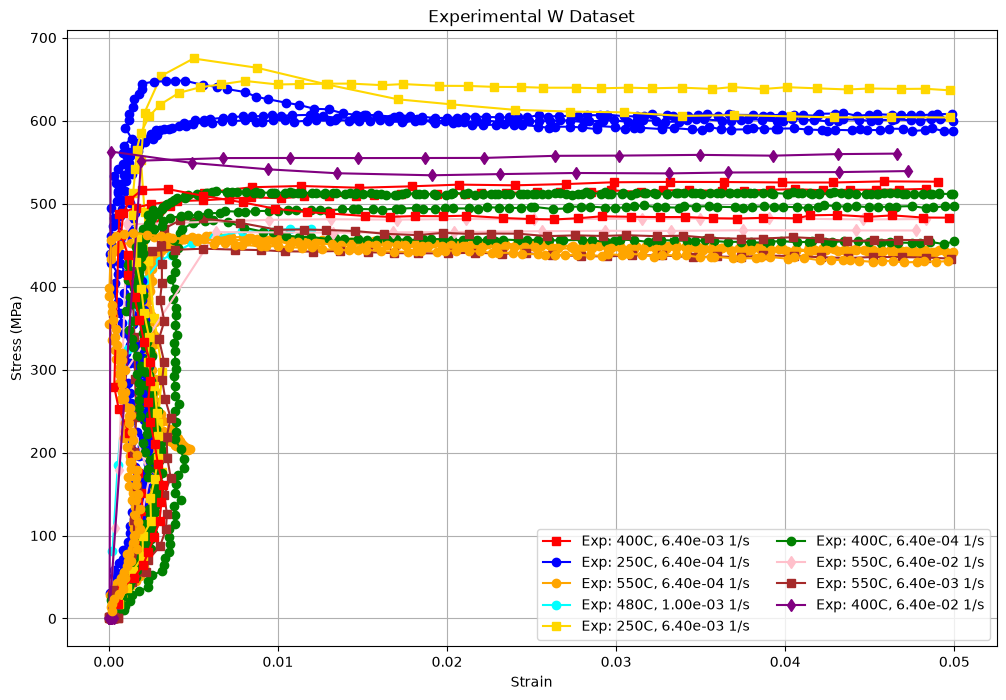

In [ ]:
# Load experimental data
path = '/home/colinmg/neml2/cmg_projects/stress-strain/tensile_data/W_test_data'
data_frames = {}
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        sample_name = filename.split('_')[1]
        if '250C' in filename:
            temp_str = 250
            if sample_name in ['C101', 'C104', 'C107']:
                strain_rate_str = 6.4e-4
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ['C115', 'C116']:
                strain_rate_str = 6.4e-3
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            else:
                strain_rate_str = None
        elif '400C' in filename:
            temp_str = 400
            if sample_name in ['C102', 'C105', 'C108']:
                strain_rate_str = 6.4e-4
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ['C114', 'C117', 'C123']:
                strain_rate_str = 6.4e-3
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ['C113', 'C118']:
                strain_rate_str = 6.4e-2
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            else:
                strain_rate_str = None
        elif '550C' in filename:
            temp_str = 550
            if sample_name in ['C103', 'C106', 'C109']:
                strain_rate_str = 6.4e-4
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ['C119', 'C120']:
                strain_rate_str = 6.4e-3
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            elif sample_name in ['C121', 'C122']:
                strain_rate_str = 6.4e-2
                label = f"{sample_name}: {temp_str}C, {strain_rate_str:.2e} 1/s"
            else:
                strain_rate_str = None
        elif '480C' in filename:
            temp_str = 480
            strain_rate_str = 1.0e-3
            label = f"{temp_str}C, {strain_rate_str:.2e} 1/s"
        else:
            # Skip CSV files that are not part of the deterministic calibration set. This excludes 300C dataset
            continue
        
        new_df = df.rename(columns={'x':f'{label}_strain', 'y':f'{label}_stress'})
        data_frames[label] = new_df

strain_data = {}
stress_data = {}

for label, df in data_frames.items():
    strain_col = f'{label}_strain'
    stress_col = f'{label}_stress'
    if ": " in label:
        strain = torch.tensor(df[strain_col].values, device=device)
    else:
        strain = torch.tensor(df[strain_col].values *1e-2, device=device)

    stress = torch.tensor(df[stress_col].values, device=device)

    strain = strain[:] - strain[0]
    stress = stress[:] - stress[0]

    mask = (stress > 0) & (strain <= 0.05) & (strain > 0)
    strain = strain[mask]
    stress = stress[mask]

    strain_data[label] = strain
    stress_data[label] = stress

exp_conditions = []
for label, df in data_frames.items():
    if ':' in label:
        temp_str = re.split(r'[:,]', label)[1]
        strain_rate_str = re.split(r'[:,]', label)[2]
    else:
        temp_str = label.split(',')[0]
        strain_rate_str = label.split(',')[1]

    temp = float(temp_str.replace('C', '').strip()) + 273.15 # convert to Kelvin
    strain_rate = float(strain_rate_str.replace('1/s', '').strip())
    exp_conditions.append((temp, strain_rate, label))

for i, (temp, rate, label) in enumerate(exp_conditions):
    min_strain = strain_data[label].min().item()
    max_strain = strain_data[label].max().item()
    
    # Experimental strain ranges
    print(f"{label}: strain range [{min_strain:.4f}, {max_strain:.4f}]")

style_map = {
    (250, 6.4e-4): ('blue',   'o'),
    (250, 6.4e-3): ('gold',   's'),
    (400, 6.4e-4): ('green',  'o'),
    (400, 6.4e-3): ('red',    's'),
    (400, 6.4e-2): ('purple', 'd'),
    (480, 1.0e-3): ('cyan',   'o'),
    (550, 6.4e-4): ('orange', 'o'),
    (550, 6.4e-3): ('brown',  's'),
    (550, 6.4e-2): ('pink',   'd'),
}

# Plot initial dataset
plt.figure(figsize=(12,8))
plotted_conditions = set()
for label in strain_data:
    T_exp = next(T for T, r, l in exp_conditions if l == label)
    rate_exp = next(r for T, r, l in exp_conditions if l == label)
    temp_C = round(T_exp - 273.15)
    color, marker = style_map.get((temp_C, rate_exp), ('k', 'o'))

    # Only add one legend entry per condition (not one per replicate)
    cond_key = (temp_C, rate_exp)
    legend_label = f"Exp: {temp_C}C, {rate_exp:.2e} 1/s" if cond_key not in plotted_conditions else "_nolegend_"
    plotted_conditions.add(cond_key)
    plt.plot(strain_data[label].cpu().numpy(), stress_data[label].cpu().numpy(),color=color, marker=marker, label=legend_label)
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Experimental W Dataset')
plt.grid()
plt.legend(loc='lower right', ncol=2)
plt.show()

In [14]:
batch_conditions = [
    (523.15, 6.4e-4),
    (523.15, 6.4e-3),
    (673.15, 6.4e-4),
    (673.15, 6.4e-3),
    (673.15, 6.4e-2),
    (753.15, 1.0e-3),
    (823.15, 6.4e-4),
    (823.15, 6.4e-3),
    (823.15, 6.4e-2)
]

temperatures = torch.tensor([c[0] for c in batch_conditions], device=device)
rates = torch.tensor([c[1] for c in batch_conditions], device=device)

nbatch = len(batch_conditions)
ntime = 200

time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, (T, rate) in enumerate(batch_conditions):
    max_strain = 0.05
    strain_values = torch.linspace(0.0, max_strain, ntime, device=device)
    time_values = torch.linspace(0.0, max_strain/rate, ntime, device=device)
    loading[:, i, 0] = strain_values
    time[:, i, 0] = time_values
    
    # Set temperature (in Kelvin)
    temperature[:, i, 0] = T

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")



--- Full Input Tensors ---
time: torch.Size([200, 9, 1])
temperature: torch.Size([200, 9, 1])
loading: torch.Size([200, 9, 6])


    Batch 0 250C 6.40e-04 1/s -> 3 curves: ['C104: 250C, 6.40e-04 1/s', 'C107: 250C, 6.40e-04 1/s', 'C101: 250C, 6.40e-04 1/s']
    Batch 1 250C 6.40e-03 1/s -> 2 curves: ['C115: 250C, 6.40e-03 1/s', 'C116: 250C, 6.40e-03 1/s']
    Batch 2 400C 6.40e-04 1/s -> 3 curves: ['C102: 400C, 6.40e-04 1/s', 'C108: 400C, 6.40e-04 1/s', 'C105: 400C, 6.40e-04 1/s']
    Batch 3 400C 6.40e-03 1/s -> 3 curves: ['C114: 400C, 6.40e-03 1/s', 'C123: 400C, 6.40e-03 1/s', 'C117: 400C, 6.40e-03 1/s']
    Batch 4 400C 6.40e-02 1/s -> 2 curves: ['C118: 400C, 6.40e-02 1/s', 'C113: 400C, 6.40e-02 1/s']
    Batch 5 480C 1.00e-03 1/s -> 1 curves: ['480C, 1.00e-03 1/s']
    Batch 6 550C 6.40e-04 1/s -> 3 curves: ['C109: 550C, 6.40e-04 1/s', 'C106: 550C, 6.40e-04 1/s', 'C103: 550C, 6.40e-04 1/s']
    Batch 7 550C 6.40e-03 1/s -> 2 curves: ['C120: 550C, 6.40e-03 1/s', 'C119: 550C, 6.40e-03 1/s']
    Batch 8 550C 6.40e-02 1/s -> 2 curves: ['C121: 550C, 6.40e-02 1/s', 'C122: 550C, 6.40e-02 1/s']
Interpolated data shap

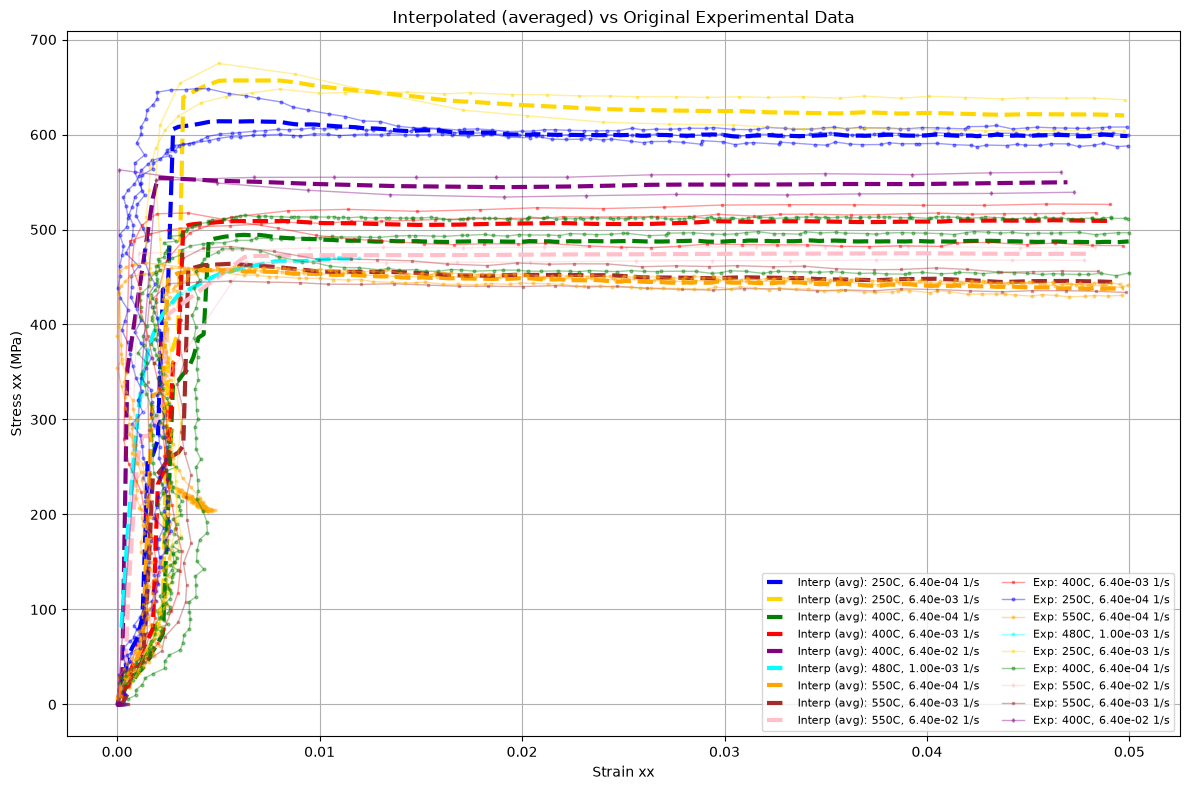

In [15]:
exp_stress_data = torch.zeros_like(loading, device=device)
exp_strain_data = torch.zeros_like(loading, device=device)

batch_to_labels = defaultdict(list)
for i, (bT, b_rate) in enumerate(batch_conditions):
    for j, (T, rate, label) in enumerate(exp_conditions):
        if abs(T - bT) == 0.0 and abs(rate - b_rate) == 0.0:
            batch_to_labels[i].append(label)

for i, (T, rate) in enumerate(batch_conditions):
    labels = batch_to_labels.get(i, [])
    print(f'    Batch {i:d} {T-273.15:.0f}C {rate:.2e} 1/s -> {len(labels)} curves: {labels}')

    # Model loading is in strain fraction; experimental data is in percent.
    target_strain = loading[:, i, 0].cpu().numpy()
    
    replicate_strains = []
    replicate_stresses = []

    for label in labels:
        src_strain = strain_data[label].cpu().numpy()
        src_stress = stress_data[label].cpu().numpy()

        tgt_clipped = np.clip(target_strain, src_strain.min(), src_strain.max())
        interp_stress = np.interp(tgt_clipped, src_strain, src_stress)

        replicate_strains.append(tgt_clipped)
        replicate_stresses.append(interp_stress)

    mean_strain = np.mean(replicate_strains, axis=0)
    mean_stress = np.mean(replicate_stresses, axis=0)

    exp_strain_data[:, i, 0] = torch.tensor(mean_strain, device=device)
    exp_stress_data[:, i, 0] = torch.tensor(mean_stress, device=device)
 
print(f"Interpolated data shape:")
print(f"strain: {exp_strain_data.shape}")
print(f"stress: {exp_stress_data.shape}")

print("Saturated Stress values")
for i, (T, rate) in enumerate(batch_conditions):
    print(f'  Batch {i} {T-273.15}C {rate:.2e} 1/s -> {exp_stress_data[-1, i, 0].item():.2f} MPa')

# Color/marker scheme keyed by (temp_C, rate)
style_map = {
    (250, 6.4e-4): ('blue',   'o'),
    (250, 6.4e-3): ('gold',   's'),
    (400, 6.4e-4): ('green',  'o'),
    (400, 6.4e-3): ('red',    's'),
    (400, 6.4e-2): ('purple', 'd'),
    (480, 1.0e-3): ('cyan',   'o'),
    (550, 6.4e-4): ('orange', 'o'),
    (550, 6.4e-3): ('brown',  's'),
    (550, 6.4e-2): ('pink',   'd'),
}

fig, ax = plt.subplots(figsize=(12, 8))

# ── Interpolated (averaged) curves ──────────────────────────────────────────
for i, (T, rate) in enumerate(batch_conditions):
    temp_C = round(T - 273.15)
    color, _ = style_map.get((temp_C, rate), (f'C{i}', 'o'))
    batch_label = f"{temp_C}C, {rate:.2e} 1/s"
    ax.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        '--', color=color, lw=3,
        label=f"Interp (avg): {batch_label}",
    )

# ── Original replicate curves ────────────────────────────────────────────────
plotted_conditions = set()
for label in strain_data:
    T_exp = next(T for T, r, l in exp_conditions if l == label)
    rate_exp = next(r for T, r, l in exp_conditions if l == label)
    temp_C = round(T_exp - 273.15)
    color, marker = style_map.get((temp_C, rate_exp), ('k', 'o'))

    # Only add one legend entry per condition (not one per replicate)
    cond_key = (temp_C, rate_exp)
    legend_label = f"Exp: {temp_C}C, {rate_exp:.2e} 1/s" if cond_key not in plotted_conditions else "_nolegend_"
    plotted_conditions.add(cond_key)

    ax.plot(
        strain_data[label].cpu().numpy(),
        stress_data[label].cpu().numpy(),
        color=color, alpha=0.4, lw=1, marker=marker, markersize=2,
        label=legend_label,
    )

ax.set_xlabel("Strain xx")
ax.set_ylabel("Stress xx (MPa)")
ax.set_title("Interpolated (averaged) vs Original Experimental Data")
ax.grid(True)
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

In [16]:
with torch.no_grad():
    stress = model(time, temperature, loading)
print(stress)
print(stress.shape)

tensor([[[   0.0000],
         [   0.0000],
         [   0.0000],
         ...,
         [   0.0000],
         [   0.0000],
         [   0.0000]],

        [[ 103.0146],
         [ 103.0150],
         [ 102.9901],
         ...,
         [ 102.7120],
         [ 102.9845],
         [ 103.0120]],

        [[ 206.0256],
         [ 206.0297],
         [ 205.8308],
         ...,
         [ 203.8647],
         [ 205.8085],
         [ 206.0079]],

        ...,

        [[2066.5650],
         [2662.6531],
         [1564.1868],
         ...,
         [1166.4015],
         [1831.3645],
         [2680.3084]],

        [[2066.7128],
         [2662.8564],
         [1564.3285],
         ...,
         [1166.5319],
         [1831.5645],
         [2680.6282]],

        [[2066.8573],
         [2663.0552],
         [1564.4671],
         ...,
         [1166.6594],
         [1831.7600],
         [2680.9409]]], device='cuda:0')
torch.Size([200, 9, 1])


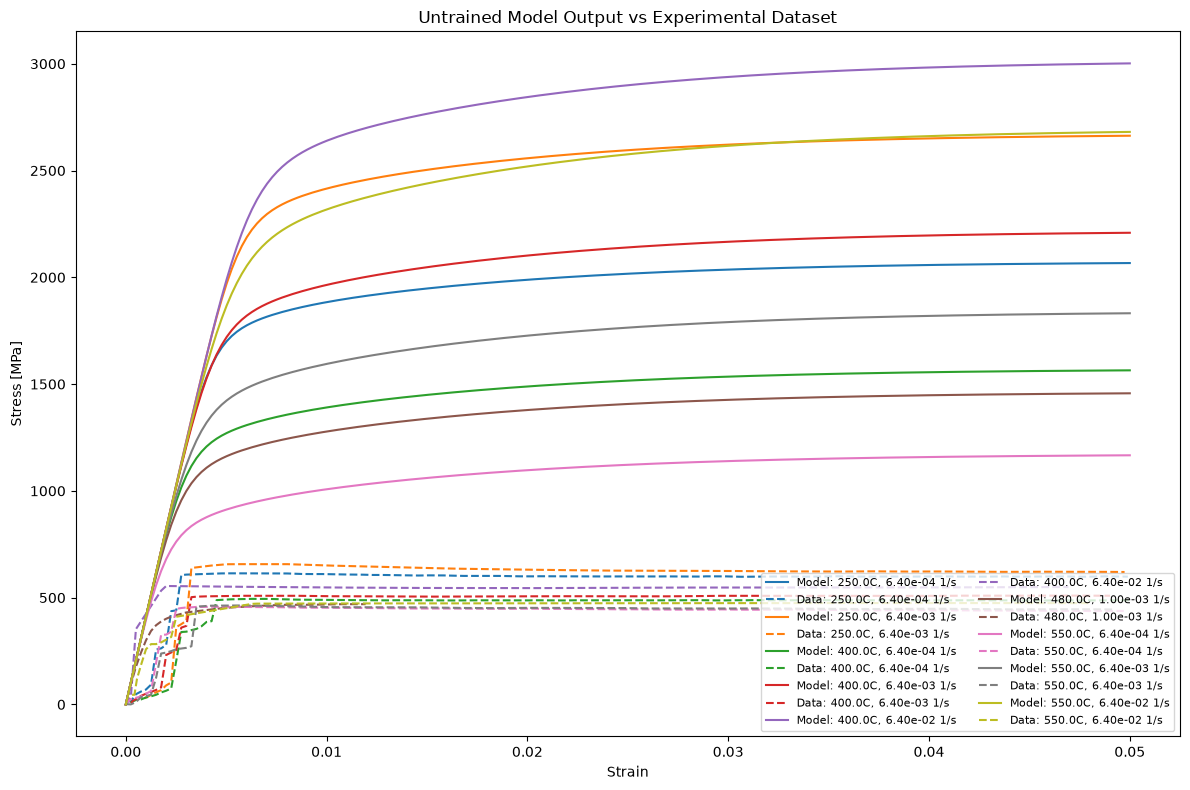

In [17]:
plt.figure(figsize=(12,8))
for i, (T, rate) in enumerate(batch_conditions):
    batch_label = f'{T - 273.15}C, {rate:.2e} 1/s'
    plt.plot(loading[:, i, 0].cpu().numpy(), stress[:, i, 0].cpu().numpy(), color=f'C{i}', label=f'Model: {batch_label}')
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), '--',color=f'C{i}', label=f'Data: {batch_label}')
plt.legend(loc='lower right', fontsize=8, ncol=2)
plt.xlabel('Strain')
plt.ylabel('Stress [MPa]')
plt.title('Untrained Model Output vs Experimental Dataset')
plt.tight_layout()
plt.show()

Available state variables:
  state/internal/X
  state/internal/rho_m
  state/mixed_state
Available force variables:
  forces/T
  forces/control
  forces/fixed_values
  forces/t

Batch    T_f (expected)    T_f in forces/T    Match           E          nu           G     sigma_a
    0            523.15             523.15        ✓   410000.00       0.280   160156.25       21.91
    1            523.15             523.15        ✓   410000.00       0.280   160156.25       21.91
    2            673.15             673.15        ✓   410000.00       0.280   160156.25       21.91
    3            673.15             673.15        ✓   410000.00       0.280   160156.25       21.91
    4            673.15             673.15        ✓   410000.00       0.280   160156.25       21.91
    5            753.15             753.15        ✓   410000.00       0.280   160156.25       21.91
    6            823.15             823.15        ✓   410000.00       0.280   160156.25       21.91
    7            823.1

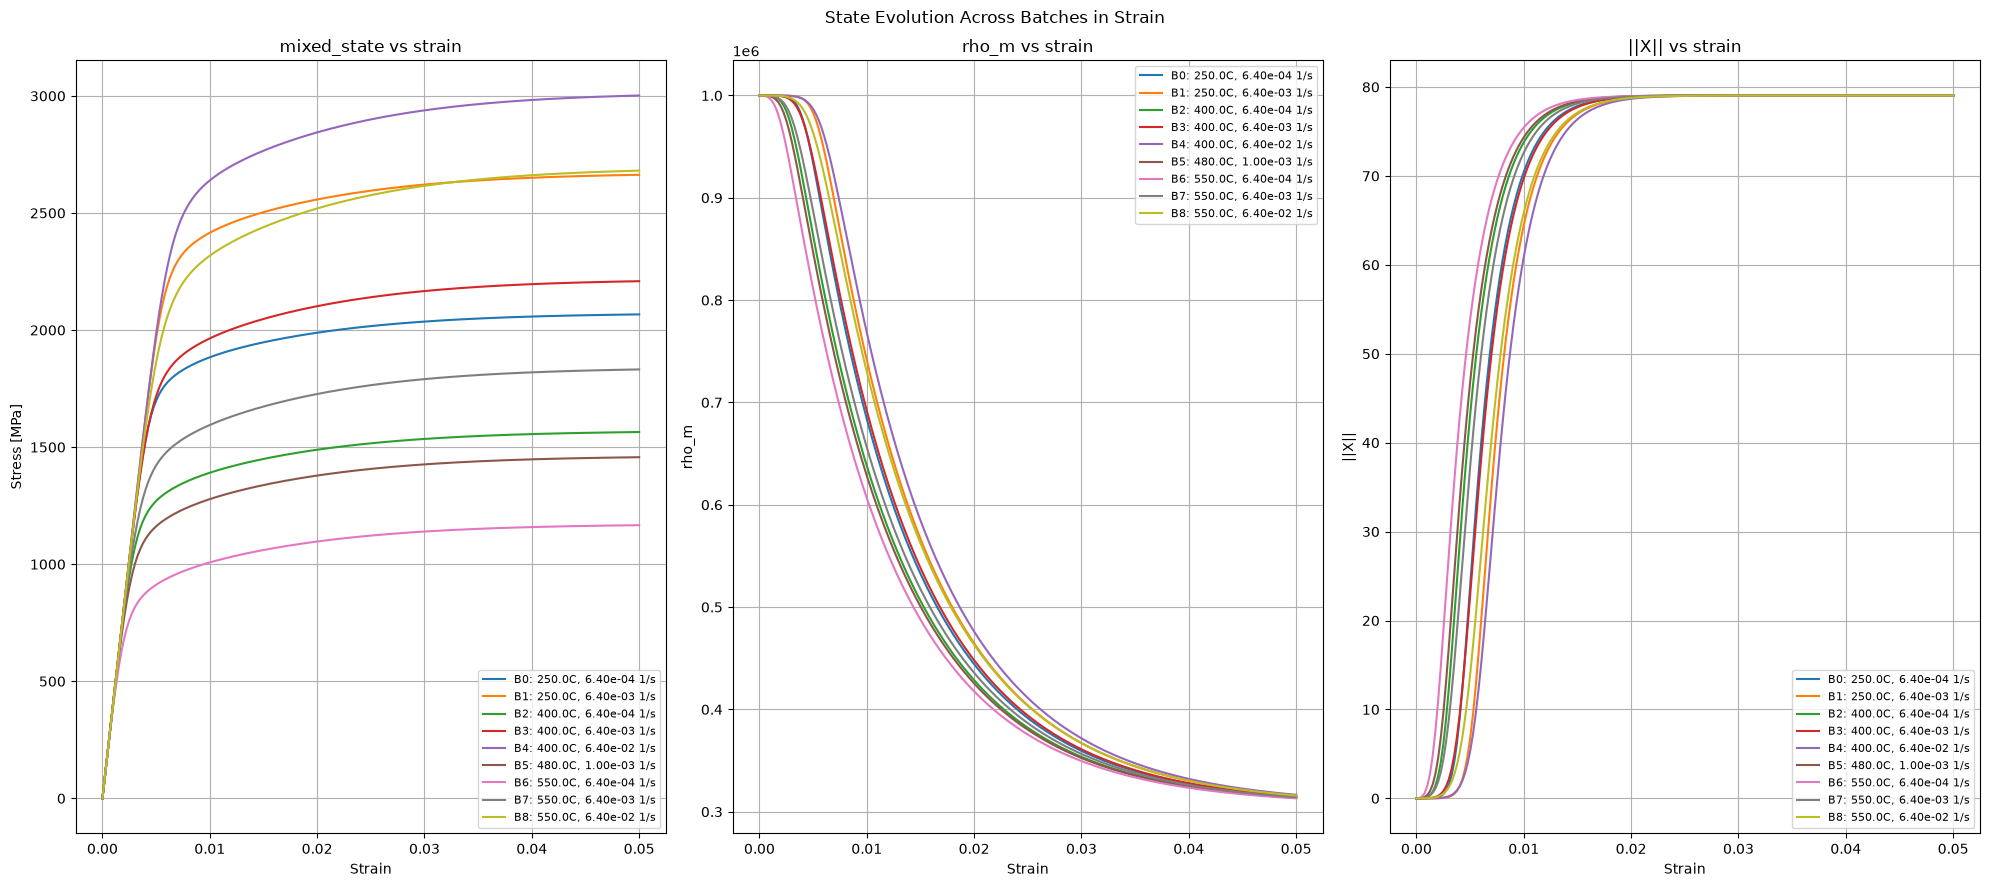

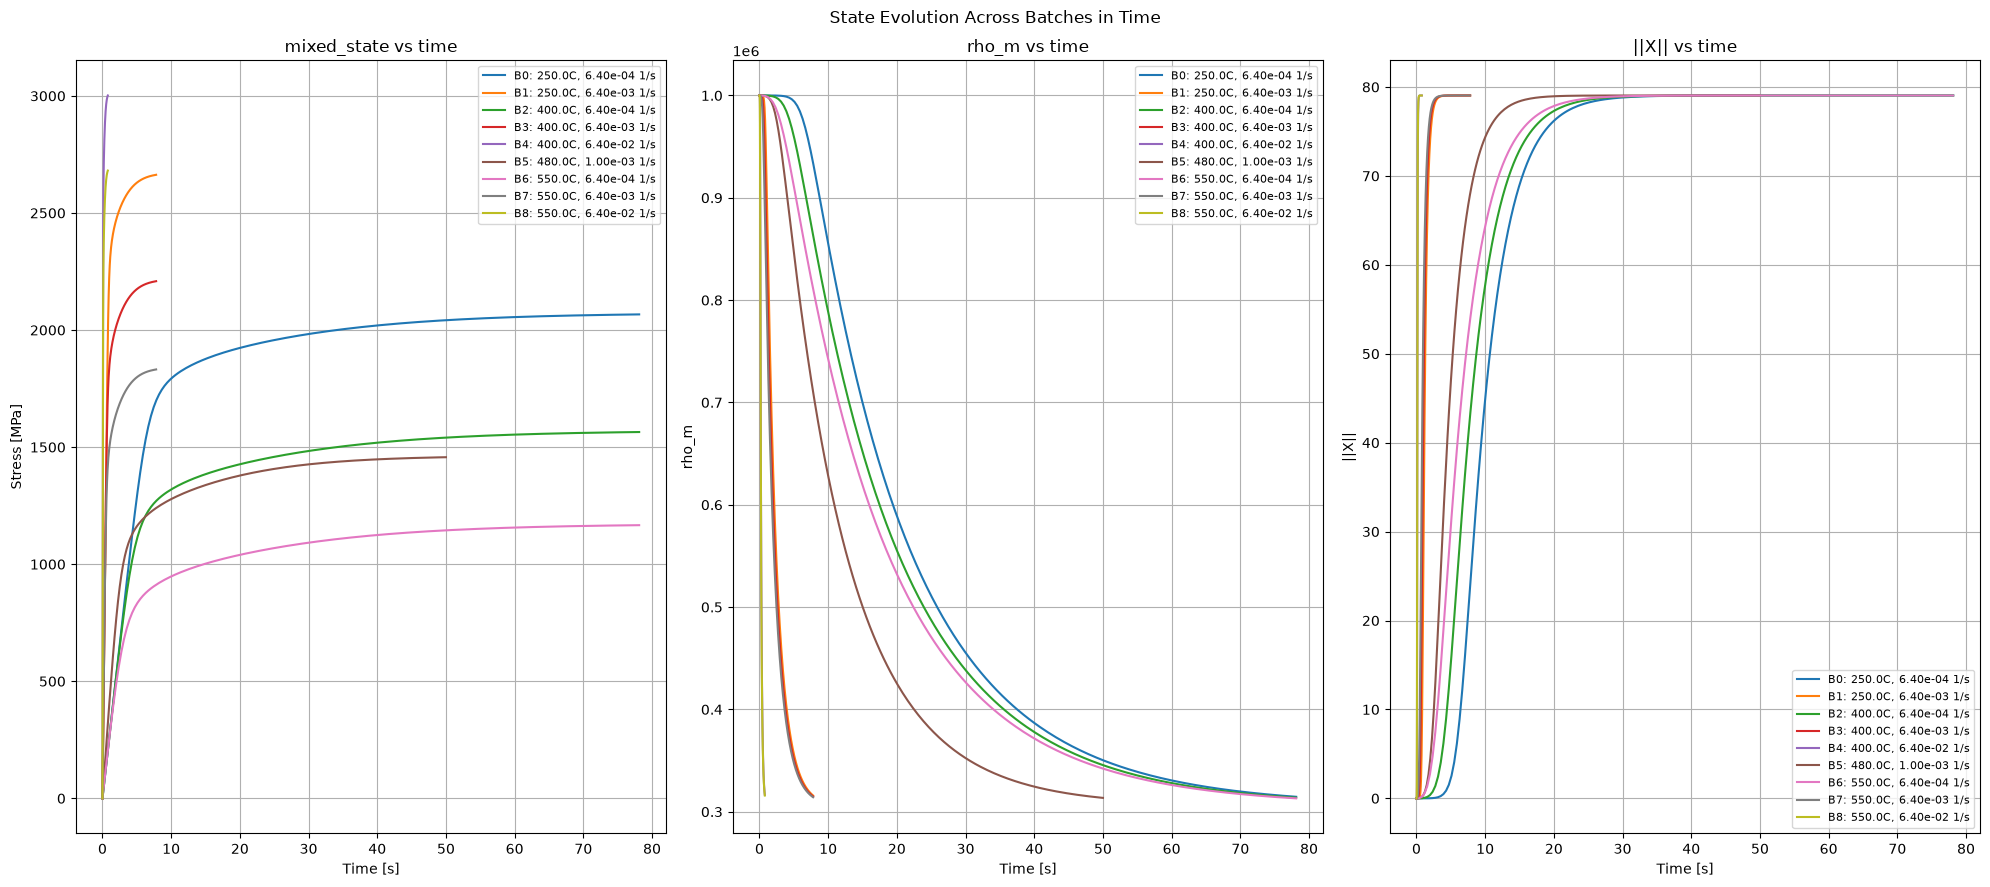

In [20]:
# Debug: inspect internal-variable evolution over time; overlay all batches on two 2x2 figures
with torch.no_grad():
    dbg_solver = nonlinear.RecursiveNonlinearEquationSolver(
        model.discrete_equations,
        step_generator=nonlinear.StepGenerator(model.nchunk),
        predictor=nonlinear.PreviousStepsPredictor(),
        nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=model.rtol, atol=model.atol),
    )

    dbg_control = torch.zeros_like(loading)
    dbg_control[..., 1:] = 1.0

    dbg_forces = model.discrete_equations.forces_asm.assemble_by_variable(
        {
            "forces/t": time,
            "forces/control": dbg_control,
            "forces/T": temperature,
            "forces/fixed_values": loading,
        }
    ).torch()

    dbg_state0 = model.discrete_equations.state_asm.assemble_by_variable(
        {
            "state/internal/rho_m": torch.full(
                dbg_forces.shape[1:-1] + (1,), model.initial_rho_m, device=dbg_forces.device
            )
        }
    ).torch()

    dbg_results = nonlinear.solve_adjoint(dbg_solver, dbg_state0, len(dbg_forces), dbg_forces)

# Convert VariableName keys to strings for safe filtering/sorting/indexing
state_hist_raw = model.discrete_equations.state_asm.split_by_variable(neml2.Tensor(dbg_results, 2))
state_hist = {str(k): v for k, v in state_hist_raw.items()}

forces_hist_raw = model.discrete_equations.forces_asm.split_by_variable(neml2.Tensor(dbg_forces, 1))
forces_hist = {str(k): v.torch() for k, v in forces_hist_raw.items()}

state_names = sorted(state_hist.keys())
print("Available state variables:")
for name in state_names:
    print(" ", name)

forces_names = sorted(forces_hist.keys())
print("Available force variables:")
for name in forces_names:
    print(" ", name)

def get_hist(axis, name):
    return axis[name].torch() if name in state_hist else None

T_in_forces = forces_hist["forces/T"]

E = nmodel.elasticity_E.tensor()
nu = nmodel.elasticity_nu.tensor()
alpha = nmodel.athermal_alpha.tensor()
b = nmodel.athermal_b.tensor()
init_rho_m = model.initial_rho_m
L_init = 1 / np.sqrt(init_rho_m)

print(f"\n{'Batch':>5}  {'T_f (expected)':>16}  {'T_f in forces/T':>17}  {'Match':>7}  {'E':>10}  {'nu':>10}  {'G':>10}  {'sigma_a':>10}")
for i, (T_f, rate) in enumerate(batch_conditions):
    T_first = T_in_forces[0,  i, 0].item()
    T_last  = T_in_forces[-1, i, 0].item()
    match = "✓" if abs(T_first - T_f) == 0 and abs(T_last - T_f) == 0 else "✗ MISMATCH"
    G = E / (2.0 * (1.0 + nu))
    sigma_a = (alpha * G * b) / L_init

    print(f"  {i:>3}  {T_f:>16.2f}  {T_first:>17.2f}  {match:>7}  {E.item():>10.2f}  {nu.item():>10.3f}  {G.item():>10.2f}  {sigma_a.item():>10.2f}")

rho_m = get_hist(state_hist, "state/internal/rho_m")
X = get_hist(state_hist, "state/internal/X")

fig_s, ax_s = plt.subplots(1, 3, figsize=(20, 9))
fig_s.suptitle("State Evolution Across Batches in Strain")

fig_t, ax_t = plt.subplots(1, 3, figsize=(20, 9))
fig_t.suptitle("State Evolution Across Batches in Time")

for i, T in enumerate(temperatures):
    strain_hist = loading[:, i, 0].detach().cpu()
    time_hist = time[:, i, 0].detach().cpu()
    stress11 = stress[:, i, 0].detach().cpu() if stress is not None else None
    rho_m_hist = rho_m[:, i, 0].detach().cpu() if rho_m is not None else None
    x_norm_hist = torch.linalg.norm(X[:, i, :], dim=-1).detach().cpu() if X is not None else None

    temp_c = T.item() - 273.15
    rate_i = rates[i].item()
    label = f"B{i}: {temp_c:.1f}C, {rate_i:.2e} 1/s"

    print(f"\nBatch {i}: T={temp_c:.1f}C, rate={rate_i:.3e} 1/s")
    if rho_m_hist is not None:
        print(f"rho_m: start={rho_m_hist[0].item():.6e}, end={rho_m_hist[-1].item():.6e}")
    if x_norm_hist is not None:
        print(f"||X||: start={x_norm_hist[0].item():.6e}, end={x_norm_hist[-1].item():.6e}")

    if stress11 is not None:
        ax_s[0].plot(strain_hist.numpy(), stress11.numpy(), label=label)
        ax_t[0].plot(time_hist.numpy(), stress11.numpy(), label=label)
    if rho_m_hist is not None:
        ax_s[1].plot(strain_hist.numpy(), rho_m_hist.numpy(), label=label)
        ax_t[1].plot(time_hist.numpy(), rho_m_hist.numpy(), label=label)
    if x_norm_hist is not None:
        ax_s[2].plot(strain_hist.numpy(), x_norm_hist.numpy(), label=label)
        ax_t[2].plot(time_hist.numpy(), x_norm_hist.numpy(), label=label)

ax_s[0].set_title("mixed_state vs strain")
ax_s[0].set_xlabel("Strain")
ax_s[0].set_ylabel("Stress [MPa]")
ax_s[0].grid(True)
ax_s[0].legend(fontsize=8)

ax_s[1].set_title("rho_m vs strain")
ax_s[1].set_xlabel("Strain")
ax_s[1].set_ylabel("rho_m")
ax_s[1].grid(True)
ax_s[1].legend(fontsize=8)

ax_s[2].set_title("||X|| vs strain")
ax_s[2].set_xlabel("Strain")
ax_s[2].set_ylabel("||X||")
ax_s[2].grid(True)
ax_s[2].legend(fontsize=8)

ax_t[0].set_title("mixed_state vs time")
ax_t[0].set_xlabel("Time [s]")
ax_t[0].set_ylabel("Stress [MPa]")
ax_t[0].grid(True)
ax_t[0].legend(fontsize=8)

ax_t[1].set_title("rho_m vs time")
ax_t[1].set_xlabel("Time [s]")
ax_t[1].set_ylabel("rho_m")
ax_t[1].grid(True)
ax_t[1].legend(fontsize=8)

ax_t[2].set_title("||X|| vs time")
ax_t[2].set_xlabel("Time [s]")
ax_t[2].set_ylabel("||X||")
ax_t[2].grid(True)
ax_t[2].legend(fontsize=8)

fig_s.tight_layout()
fig_t.tight_layout()
plt.show()

In [21]:
initial_params = {}
print("--- Before Reparametrization ---")
for n, p in model.named_parameters():
    initial_params[n] = p.data.detach().clone()
    print(f"{n}: {p.data}, {p.shape}\n")

--- Before Reparametrization ---
discrete_equations.kinharden_C: tensor([41500.], device='cuda:0'), torch.Size([1])

discrete_equations.kinharden_g: tensor([350.], device='cuda:0'), torch.Size([1])

discrete_equations.rho_m_rate_k1: tensor([83000.], device='cuda:0'), torch.Size([1])

discrete_equations.rho_m_rate_k2: tensor([150.], device='cuda:0'), torch.Size([1])

discrete_equations.v_disl_Bk: tensor([8.3000e-06], device='cuda:0'), torch.Size([1])

discrete_equations.v_disl_T_0: tensor([2956.], device='cuda:0'), torch.Size([1])



In [22]:
C_scaler = reparametrization.RangeRescale(torch.tensor([100.0], device=device), torch.tensor([100000.0], device=device))     # MPa
g_scaler = reparametrization.RangeRescale(torch.tensor([0.01], device=device), torch.tensor([500.0], device=device))        # unitless
k1_scaler = reparametrization.RangeRescale(torch.tensor([10.0], device=device), torch.tensor([1.0e7], device=device))      # mm^-1
k2_scaler = reparametrization.RangeRescale(torch.tensor([0.01], device=device), torch.tensor([500.0], device=device))       # unitless
Bk_scaler = reparametrization.RangeRescale(torch.tensor([1.0e-20], device=device), torch.tensor([5.0e-3], device=device))   # MPa*s
T_0_scaler = reparametrization.RangeRescale(torch.tensor([2000.0], device=device), torch.tensor([5000.0], device=device))   # K

model_reparameterizer = reparametrization.Reparameterizer(
    {
        "discrete_equations.kinharden_C" : C_scaler,
        "discrete_equations.kinharden_g" : g_scaler,
        "discrete_equations.rho_m_rate_k1" : k1_scaler,
        "discrete_equations.rho_m_rate_k2" : k2_scaler,
        "discrete_equations.v_disl_Bk" : Bk_scaler,
        "discrete_equations.v_disl_T_0" : T_0_scaler}, error_not_provided=True)
model_reparameterizer(model)
print(f'--- After Reparameterization ---')
initial_params_reparam = {}
for n, p in model.named_parameters():
    initial_params_reparam[n] = p.data.detach().clone()
    print(f'{n}: {p.data}, requires_grad={p.requires_grad}')

--- After Reparameterization ---
discrete_equations.parametrizations.kinharden_C.original: tensor([0.4144], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.kinharden_g.original: tensor([0.7000], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.rho_m_rate_k1.original: tensor([0.0083], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.rho_m_rate_k2.original: tensor([0.3000], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.v_disl_Bk.original: tensor([0.0017], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.v_disl_T_0.original: tensor([0.3187], device='cuda:0'), requires_grad=True


In [31]:
N_SAMPLES = 200
N_TOP = 10

PARAM_META = [
    ("C", 100.0, 100000.0, False),
    ("g", 0.01, 500.0, False),
    ("k1", 10.0, 1.0e7, True),
    ("k2", 0.01, 500.0, False),
    ("Bk", 1.0e-20, 5.0e-3, True),
    ("T_0", 2000.0, 5000.0, False)
]

PARAM_PATHS = {
    "Bk"   : "discrete_equations.parametrizations.v_disl_Bk.original",
    "C"    : "discrete_equations.parametrizations.kinharden_C.original",
    "T_0"  : "discrete_equations.parametrizations.v_disl_T_0.original",
    "g"    : "discrete_equations.parametrizations.kinharden_g.original",
    "k1"   : "discrete_equations.parametrizations.rho_m_rate_k1.original",
    "k2"   : "discrete_equations.parametrizations.rho_m_rate_k2.original"
}

n_dim = len(PARAM_META)
sampler = qmc.LatinHypercube(d=n_dim)
unit_samples = sampler.random(n=N_SAMPLES)

physical_samples = np.zeros_like(unit_samples)
for i, (name, lb, ub, use_log) in enumerate(PARAM_META):
    physical_samples = qmc.scale(unit_samples, lb, ub)

param_values = torch.tensor(physical_samples, dtype=torch.double, device=device)
print(param_values)
print(param_values.shape)

C = nmodel.kinharden_C.tensor().torch()
g = nmodel.kinharden_g.tensor().torch()
k1 = nmodel.rho_m_rate_k1.tensor().torch()
k2 = nmodel.rho_m_rate_k2.tensor().torch()
Bk = nmodel.v_disl_Bk.tensor().torch()
T_0 = nmodel.v_disl_T_0.tensor().torch()

original_state = copy.deepcopy(model.state_dict())
loss_fn_lhs = torch.nn.MSELoss()
results = []

titer = tqdm.tqdm(
    range(N_SAMPLES),
    bar_format="{desc}: {percentage:3.0f}%|{bar}|{n_fmt}/{total_fmt}{postfix}",
)
titer.set_description("Loss:")

for i in titer:
    
    model.load_state_dict(copy.deepcopy(original_state))
    current_state = model.state_dict()
    current_state[PARAM_PATHS["Bk"]] = param_values[i, 0].unsqueeze(0)
    current_state[PARAM_PATHS["C"]] = param_values[i, 1].unsqueeze(0)
    current_state[PARAM_PATHS["T_0"]] = param_values[i, 2].unsqueeze(0)
    current_state[PARAM_PATHS["g"]] = param_values[i, 3].unsqueeze(0)
    current_state[PARAM_PATHS["k1"]] = param_values[i ,4].unsqueeze(0)
    current_state[PARAM_PATHS["k2"]] = param_values[i, 5].unsqueeze(0)

    try:
        with torch.no_grad():
            stress_lhs = model(time, temperature, loading)

        peak_stress = exp_stress_data[-1, :, 0:1].detach()

        if stress_lhs is None or not torch.isfinite(stress_lhs).all():
            continue

        res_norm = stress_lhs / (peak_stress + 1.0e-8)
        exp_norm = exp_stress_data[...,0:1] / (peak_stress + 1.0e-8)
        loss_val = loss_fn_lhs(res_norm, exp_norm).item()

        if np.isfinite(loss_val):
            results.append((loss_val, {name: param_values[i, j].item() for j, (name, *_) in enumerate(PARAM_META)}))
        titer.set_description("Loss: %3.2e" % results[-1])

    except RuntimeError:
        continue

model.load_state_dict(original_state)

results.sort(key=lambda x: x[0])
print(f"Successful evaluations: {len(results)} / {N_SAMPLES}")
for rank, (loss_val, params) in enumerate(results[:N_TOP], 1):
    print(f"{rank:>3}: loss={loss_val:.4e}  " + "  ".join(f"{k}={v:.3e}" for k, v in params.items()))


tensor([[3916.3987, 2158.4084, 4122.4794, 4006.8273, 3865.9697, 3155.0459],
        [2793.7497, 4480.5726, 2037.3075, 2597.1030, 2257.2922, 3020.7731],
        [2819.3053, 2313.5341, 4040.8280, 3287.6271, 2762.4841, 3073.4908],
        ...,
        [4197.2379, 4099.6891, 2682.5070, 3717.4293, 3596.4919, 4100.8488],
        [3692.4068, 4805.0469, 4770.1856, 3615.8610, 4246.9804, 2934.3511],
        [3357.8876, 2169.1220, 3521.0200, 2265.9212, 3608.6481, 4887.6276]],
       device='cuda:0')
torch.Size([200, 6])


Loss:: :   0%|          |0/200


TypeError: not all arguments converted during string formatting

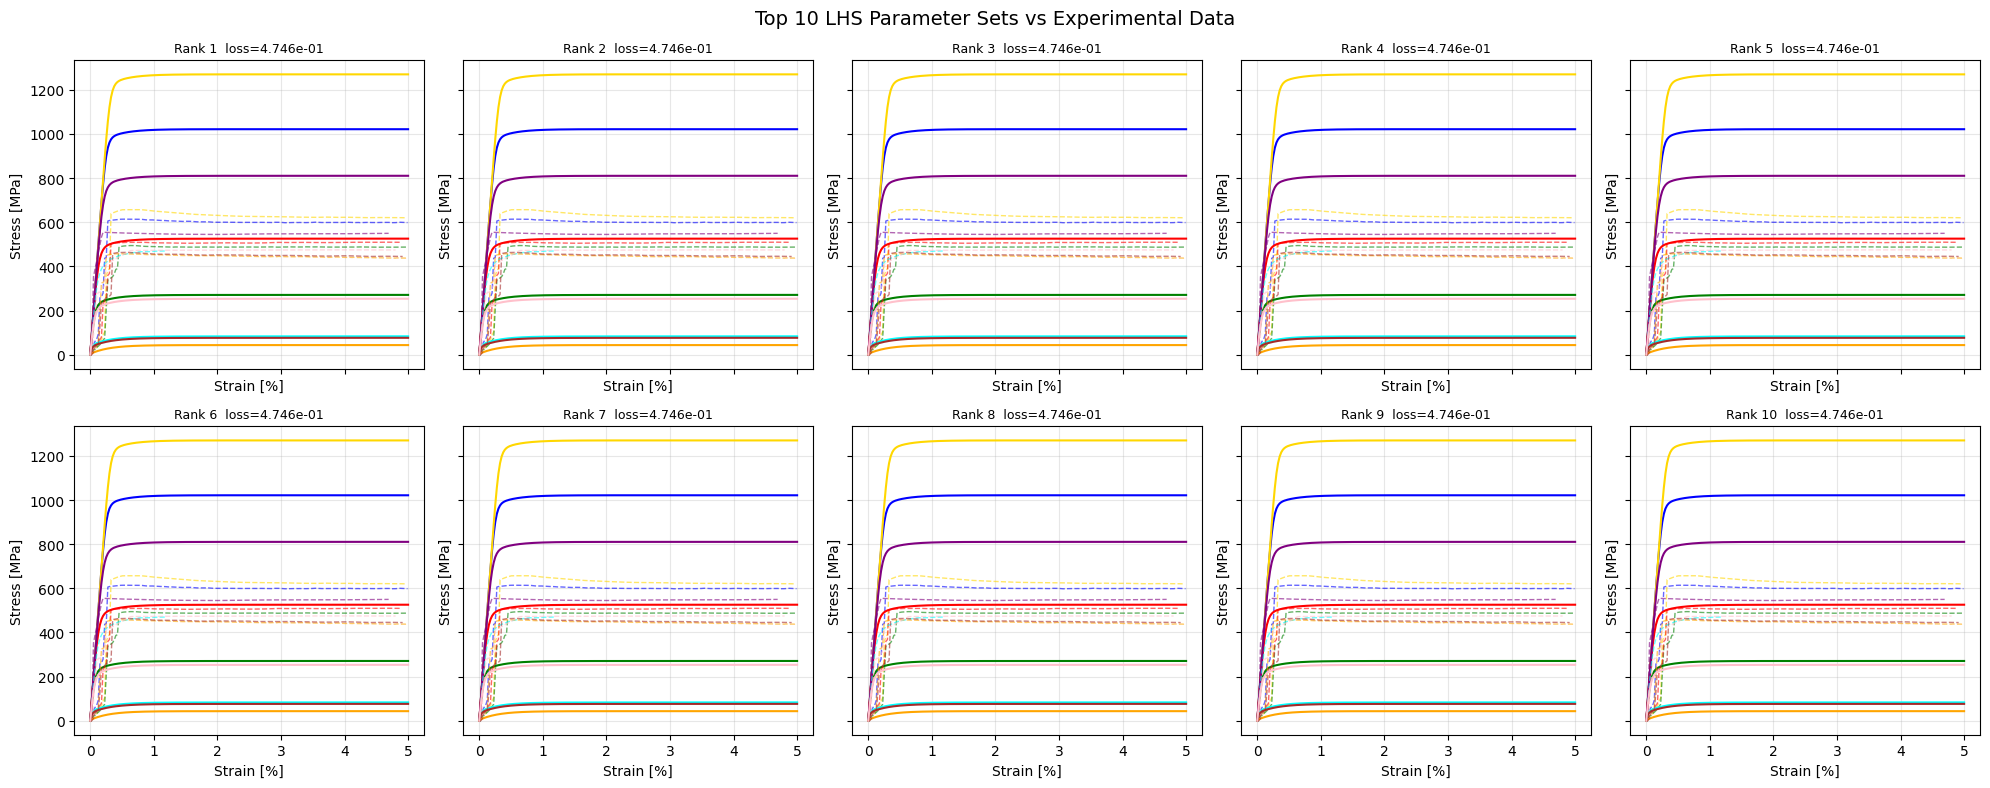

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
fig.suptitle("Top 10 LHS Parameter Sets vs Experimental Data", fontsize=14)

for rank, (ax, (loss_val, params)) in enumerate(zip(axes.flat, results[:N_TOP]), 1):

    model.load_state_dict(copy.deepcopy(original_state))
    current_state = model.state_dict()
    with torch.no_grad():
        current_state[PARAM_PATHS["Bk"]] = torch.tensor([params["Bk"]], dtype=torch.double, device=device)
        current_state[PARAM_PATHS["C"]] = torch.tensor([params["C"]], dtype=torch.double, device=device)
        current_state[PARAM_PATHS["T_0"]] = torch.tensor([params["T_0"]], dtype=torch.double, device=device)
        current_state[PARAM_PATHS["g"]] = torch.tensor([params["g"]], dtype=torch.double, device=device)
        current_state[PARAM_PATHS["k1"]] = torch.tensor([params["k1"]], dtype=torch.double, device=device)
        current_state[PARAM_PATHS["k2"]] = torch.tensor([params["k2"]], dtype=torch.double, device=device)

    try:
        with torch.no_grad():
            stress_lhs = model(time, temperature, loading)
    except RuntimeError:
        ax.set_title(f"Rank {rank} — solver fail")
        continue

    # Plot each batch condition
    for i, (T, rate) in enumerate(batch_conditions):
        temp_C = round(T - 273.15)
        color, _ = style_map.get((temp_C, rate), (f"C{i}", "o"))
        strain_plot = (loading[:, i, 0] * 100.0).cpu().numpy()

        ax.plot(strain_plot,
                stress_lhs[:, i, 0].cpu().numpy(),
                color=color, lw=1.5)
        ax.plot(exp_strain_data[:, i, 0].cpu().numpy(),
                exp_stress_data[:, i, 0].cpu().numpy(),
                "--", color=color, lw=1.0, alpha=0.6)

    ax.set_title(f"Rank {rank}  loss={loss_val:.3e}", fontsize=9)
    ax.set_xlabel("Strain [%]")
    ax.set_ylabel("Stress [MPa]")
    ax.grid(True, alpha=0.3)

# Restore original parameters when done
model.load_state_dict(original_state)

plt.tight_layout()
plt.show()

In [33]:
base_lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=base_lr)
loss_fn = torch.nn.MSELoss()
optimizer.zero_grad()

res = model(time, temperature, loading)
peak_stress = exp_stress_data[-1, :, 0:1].detach()
res_norm = res / (peak_stress + 1e-8)
exp_norm = exp_stress_data[..., 0:1] / (peak_stress + 1e-8)

loss = loss_fn(res_norm, exp_norm)
loss.backward()

for n, param in model.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.norm().item()
        target_grad = 1.0
        lr_param = base_lr * (target_grad / grad_norm)
        print(f"{n}: grad_norm = {param.grad.norm().item():.4e} | tuned LR: {lr_param:.2e}")

discrete_equations.parametrizations.kinharden_C.original: grad_norm = 2.1809e+00 | tuned LR: 4.59e-04
discrete_equations.parametrizations.kinharden_g.original: grad_norm = 1.2286e+00 | tuned LR: 8.14e-04
discrete_equations.parametrizations.rho_m_rate_k1.original: grad_norm = 5.5017e+02 | tuned LR: 1.82e-06
discrete_equations.parametrizations.rho_m_rate_k2.original: grad_norm = 1.8528e+01 | tuned LR: 5.40e-05
discrete_equations.parametrizations.v_disl_Bk.original: grad_norm = 1.8518e+03 | tuned LR: 5.40e-07
discrete_equations.parametrizations.v_disl_T_0.original: grad_norm = 9.9820e+00 | tuned LR: 1.00e-04


In [ ]:
niter = 200

param_lr_map = {
    "discrete_equations.parametrizations.kinharden_C.original"              : 4.59e-4,
    "discrete_equations.parametrizations.kinharden_g.original"              : 8.14e-4,
    "discrete_equations.parametrizations.rho_m_rate_k1.original"            : 1.82e-6,
    "discrete_equations.parametrizations.rho_m_rate_k2.original"            : 5.40e-5,
    "discrete_equations.parametrizations.v_disl_Bk.original"                : 5.40e-7,
    "discrete_equations.parametrizations.v_disl_T_0.original"               : 1.00e-4
}

param_groups = []
for name, params in model.named_parameters():
    lr = param_lr_map.get(name, 1e-3)
    param_groups.append({'params': [params], 'lr': lr})

optimizer = torch.optim.Adam(param_groups)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode='min',
    factor=0.5,
    patience=150,
    threshold=1e-4,
    min_lr=1e-7
)

titer = tqdm.tqdm(
    range(niter),
    bar_format="{desc}: {percentage:3.0f}%|{bar}|{n_fmt}/{total_fmt}{postfix}",
)
titer.set_description("Loss:")
loss_history = []

for i in titer:
    optimizer.zero_grad()
    try:
        res = model(time, temperature, loading)
        res_norm = res / (peak_stress + 1e-8)
        exp_norm = exp_stress_data[..., 0:1] / (peak_stress + 1e-8)
        loss = loss_fn(res_norm, exp_norm)

        # --- Bug fix: guard BEFORE backward ---
        if not torch.isfinite(loss) or loss.item() > 1e6:
            titer.set_description(f'Loss: [SKIP bad solve @ iter {i}]')
            continue  # skip backward + step entirely

        loss.backward()

        # Relaxed gradient clipping — 1.0 is a safe, conventional default.
        # Lower to ~0.1 if you still see instability; raise to 5.0 for faster moves.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step(loss.item())

        loss_history.append(loss.detach().clone().cpu())
        titer.set_description("Loss: %3.2e" % loss_history[-1])

    except RuntimeError:
        titer.set_description(f'Loss: [SOLVER FAIL @ iter {i}]')
        continue

# --- Plots ---
plt.figure()
plt.loglog(loss_history, label="Training")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.legend()
plt.title("Loss history")

plt.figure()
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Loss history (linear scale)")
plt.show()

Loss: [SOLVER FAIL @ iter 3]: :   2%|▏         |4/200

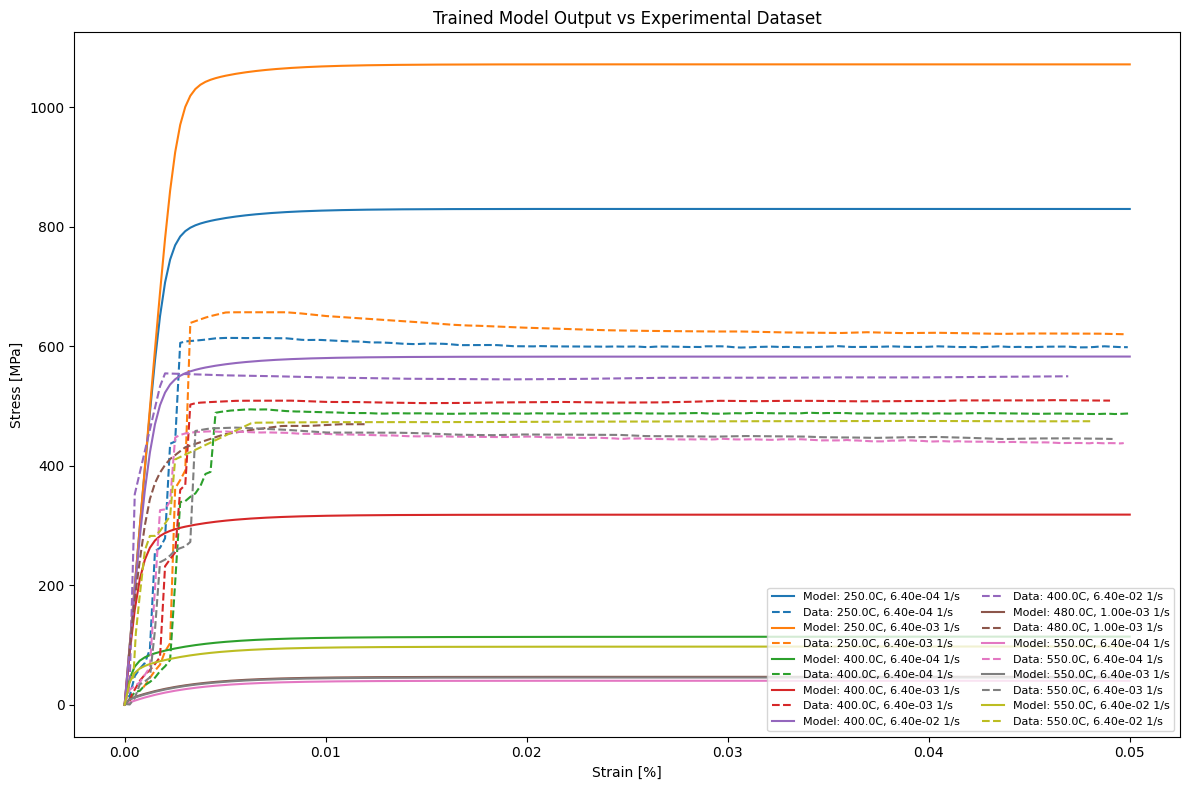

In [66]:
plt.figure(figsize=(12,8))
for i, (T, rate) in enumerate(batch_conditions):
    batch_label = f'{T - 273.15}C, {rate:.2e} 1/s'
    plt.plot(loading[:, i, 0].cpu().numpy(), res[:, i, 0].cpu().detach().numpy(), color=f'C{i}', label=f'Model: {batch_label}')
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), '--',color=f'C{i}', label=f'Data: {batch_label}')
plt.legend(loc='lower right', fontsize=8, ncol=2)
plt.xlabel('Strain [%]')
plt.ylabel('Stress [MPa]')
plt.title('Trained Model Output vs Experimental Dataset')
plt.tight_layout()
plt.show()

In [67]:
print("Parameter Optimization Results:")
print("-" * 80)
for n, p in model.named_parameters():
    parts = n.split(".")
    if "parametrizations" in parts:
        param_idx = parts.index("parametrizations")
        simple_name = parts[param_idx - 1] + "." + parts[param_idx + 1]
    scaler = model_reparameterizer.map_dict[simple_name]
    final = scaler(p.data).cpu()
    print(f"\nParameter: {n}")
    print(f"  Initial:  {initial_params[simple_name].cpu()}")
    print(f"  Final:    {final}")
print("-" * 80)

Parameter Optimization Results:
--------------------------------------------------------------------------------

Parameter: discrete_equations.parametrizations.v_disl_Bk.original
  Initial:  tensor([4.1500e-08])
  Final:    tensor([6.7005e-09])
--------------------------------------------------------------------------------


In [68]:
for i, (T, rate) in enumerate(batch_conditions):
    exp_fs = exp_stress_data[-1, i, 0].item()
    model_fs = res[-1, i, 0].item()
    diff = abs(exp_fs - model_fs)
    print(f'B{i}: ({T - 273.15}C, {rate:.2e} 1/s): Exp flow stress: {exp_stress_data[-1, i, 0].item():.2f} MPa, Model flow stress: {res[-1, i, 0].item():.2f} MPa | Diff: {diff:.2f} MPa')

B0: (250.0C, 6.40e-04 1/s): Exp flow stress: 598.44 MPa, Model flow stress: 829.79 MPa | Diff: 231.35 MPa
B1: (250.0C, 6.40e-03 1/s): Exp flow stress: 620.14 MPa, Model flow stress: 1071.81 MPa | Diff: 451.68 MPa
B2: (400.0C, 6.40e-04 1/s): Exp flow stress: 487.47 MPa, Model flow stress: 113.99 MPa | Diff: 373.48 MPa
B3: (400.0C, 6.40e-03 1/s): Exp flow stress: 509.05 MPa, Model flow stress: 318.20 MPa | Diff: 190.86 MPa
B4: (400.0C, 6.40e-02 1/s): Exp flow stress: 549.74 MPa, Model flow stress: 582.76 MPa | Diff: 33.02 MPa
B5: (480.0C, 1.00e-03 1/s): Exp flow stress: 469.51 MPa, Model flow stress: 46.69 MPa | Diff: 422.82 MPa
B6: (550.0C, 6.40e-04 1/s): Exp flow stress: 438.13 MPa, Model flow stress: 40.07 MPa | Diff: 398.06 MPa
B7: (550.0C, 6.40e-03 1/s): Exp flow stress: 444.78 MPa, Model flow stress: 45.54 MPa | Diff: 399.24 MPa
B8: (550.0C, 6.40e-02 1/s): Exp flow stress: 474.50 MPa, Model flow stress: 97.45 MPa | Diff: 377.04 MPa
